# 1일차 실습 P4 — Conv 디코더 직접 쓰기

- 수업 중 이 실습 슬라이드가 나오면 풂 · **맨 위 준비 셀부터** 위에서 아래로 실행
- 셀 실행: 셀을 누르고 **Shift + Enter** 또는 셀 왼쪽 ▶
- Colab 에서 처음 열 때 경고 창이 뜨면 '계속' · 새 파일은 준비 셀에서 데이터를 받느라 몇십 초 걸릴 수 있음
- 빈칸은 `____` · 빈칸을 모두 바꾼 뒤 **그 셀부터 다시 실행**
- 막히면 셀 이름과 **에러 칸 맨 아래 줄**을 채팅으로

## 에러를 읽는 법

- 에러 칸 첫 줄(`...Error    Traceback ...`)은 제목일 뿐 · 무엇이 틀렸는지는 **맨 아래 줄**
- 중간의 `---->` 화살표 줄 · torch 안쪽 칸은 처음엔 건너뜀 · **위에 찍힌 `[안내]` 문장과 맨 아래 줄부터** 읽음

| 맨 아래 줄에 보이는 말 | 뜻 | 먼저 볼 곳 |
|---|---|---|
| `name '____' is not defined` | 빈칸이 남음 | 화살표가 가리키는 줄 |
| `name 'nn'` · `'Xtr'` · `'MyAE'` · `'MyConvAE'` · `'크기_검사'` is not defined | 그 이름을 만든 셀을 안 돌렸거나 런타임이 끊김 | 준비 셀부터 순서대로 다시 |
| `name 'latent_dimm'` · `'Sigmoid'` · `'optimizer'` · `'ae'` is not defined | 내가 친 이름이 틀림 · 철자 · `nn.` 빠짐 · 학습 함수 안 이름은 `model` · `opt` | 화살표가 가리키는 줄 |
| `unexpected indent` · `unindent` | 줄 앞 칸 수가 위아래 줄과 다름 | 바로 위 줄과 같은 칸에서 시작하게 |
| `Perhaps you forgot a comma?` · `'(' was never closed` · `unmatched ')'` | 쉼표나 괄호 | `^` 표시 자리 |
| `mat1 and mat2 shapes cannot be multiplied (AxB and CxD)` | Linear 에 들어온 값 개수 B 와 Linear 첫 숫자 C 가 다름 | `Flatten` 과 `Linear` 첫 숫자 |
| `is not a Module subclass` | 부품 뒤 `()` 가 빠짐 | `nn.ReLU` → `nn.ReLU()` |
| `expected input[...] to have a channels, but got c channels` | 층의 첫 숫자(받는 채널)가 들어온 채널과 다름 | 마지막으로 찍힌 층의 **다음** 층 첫 숫자 |
| `The size of tensor a (..) must match the size of tensor b (..)` | 출력 크기가 정답 크기와 다름 | 층마다 찍힌 모양 · 이름의 대소문자(`x` · `X`) |

- **에러가 없는데** loss 가 0.2 근처에서 안 내려가고 그림이 회색 네모 → 학습이 안 됐을 수 있음 · `backward()` · `step()` 괄호부터 확인

## 준비

In [1]:
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision import datasets

tr = datasets.MNIST("data", train=True, download=True)
te = datasets.MNIST("data", train=False, download=True)
Xtr = tr.data.float().div(255).unsqueeze(1)   # 학습 60,000장 · 값 0~1
Xte = te.data.float().div(255).unsqueeze(1)   # 평가 10,000장
SHOW = [5459, 9898, 926, 1150, 5691, 2400, 7792, 950]   # 평가 이미지 중 숫자 0~7 한 장씩


@torch.no_grad()
def run(model, X):                      # 2,000장씩 넣어 복원을 모음
    model.eval()
    return torch.cat([model(X[i:i + 2000]) for i in range(0, len(X), 2000)])


def show(rows):                         # 같은 여덟 장을 줄마다 나란히
    fig, axes = plt.subplots(len(rows), 8, figsize=(8, 1.15 * len(rows)))
    for r, (name, X) in enumerate(rows):
        for c in range(8):
            axes[r, c].imshow(X[SHOW[c], 0], cmap="gray", vmin=0, vmax=1)
            axes[r, c].axis("off")
        axes[r, 0].set_title(name, loc="left", fontsize=10)
    plt.tight_layout()
    plt.show()


print("준비 끝 · 학습", tuple(Xtr.shape), " 평가", tuple(Xte.shape))

준비 끝 · 학습 (60000, 1, 28, 28)  평가 (10000, 1, 28, 28)


## P4. Conv 디코더 직접 쓰기

| 층 | 나오는 모양 |
|---|---|
| 입력 | 1×28×28 |
| `nn.Conv2d(1, 16, 3, stride=2, padding=1)` | 16×14×14 |
| `nn.Conv2d(16, 32, 3, stride=2, padding=1)` | 32×7×7 |
| `nn.ConvTranspose2d(?, ?, 3, stride=2, padding=1, output_padding=1)` | 16×14×14 |
| `nn.ConvTranspose2d(?, ?, 3, stride=2, padding=1, output_padding=1)` | 1×28×28 |

1. 표를 보고 디코더 뼈대의 빈칸을 채움 · 빈칸: 채널 숫자 네 개와 마지막 함수 이름 하나
   - 순서: `nn.ConvTranspose2d(받는 채널, 내보내는 채널, kernel, stride=2, padding=1, output_padding=1)`
   - 마지막 함수는 픽셀마다 값을 0~1 로 만드는 것 · 층 · 쉼표 · 괄호는 이미 적혀 있음
2. 확인 셀 실행 → 마지막 모양이 (1, 1, 28, 28) · 끝 Sigmoid 확인 · 에러가 나면 `[안내]` 문장부터
- 표의 `16×14×14` = 찍힌 모양의 끝 세 숫자(채널, 세로, 가로)
3. 맨 아래 셀로 1 에폭 학습해 내가 채운 모델의 복원 그림 보기 · 에러가 나면 `[안내]` 문장과 맨 아래 줄부터

In [2]:
class MyConvAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1), nn.ReLU(),     # 1×28×28 → 16×14×14
            nn.Conv2d(16, 32, 3, stride=2, padding=1), nn.ReLU())    # 16×14×14 → 32×7×7
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),   # 32×7×7 → 16×14×14 · 받는 채널, 내보내는 채널
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1), nn.Sigmoid())   # 16×14×14 → 1×28×28 · 끝은 0~1 로

    def forward(self, x):
        return self.decoder(self.encoder(x))

In [3]:
# P4 확인 — 층마다 모양 · 끝 함수
torch.manual_seed(0)
h = Xte[:1]
try:
    my_cae = MyConvAE()
    print("입력                 ", tuple(h.shape))
    k = 0
    for layer in list(my_cae.encoder) + list(my_cae.decoder):
        h = layer(h)
        if isinstance(layer, (nn.Conv2d, nn.ConvTranspose2d)):
            k += 1
            print(f"{k}번째 {type(layer).__name__:<16} 뒤", tuple(h.shape))
except Exception as e:
    msg = str(e)
    if "____" in msg:
        print("[안내] 빈칸 ____ 이 남아 있음 → 위 셀의 ____ 를 모두 바꾸고 위 셀부터 다시 실행")
    elif "'MyConvAE' is not defined" in msg:
        print("[안내] 위 MyConvAE 셀이 실행되지 않았거나 에러로 멈춤 → 위 셀부터 다시 실행")
    elif "channels" in msg:
        print("[안내] 채널 숫자가 맞지 않음 → 마지막으로 찍힌 층의 다음 층 첫 숫자(받는 채널) = 앞 층이 내보낸 채널")
    elif "output padding must be smaller" in msg:
        print("[안내] 뼈대에 적힌 output_padding=1 은 바꾸지 않음")
    elif "has no attribute" in msg or "is not defined" in msg:
        print("[안내] 내가 친 이름을 찾지 못함 → 철자 · 대문자 확인 · 예: nn.Sigmoid()")
    raise
print("마지막 모양이 (1, 1, 28, 28) 이면 크기는 맞음" if tuple(h.shape) == (1, 1, 28, 28) else "[안내] 마지막 모양이 (1, 1, 28, 28) 이 아님 · output_padding=1 · 채널 숫자 확인")
print("끝 Sigmoid 확인" if isinstance(my_cae.decoder[-1], nn.Sigmoid) else "[안내] 디코더 끝이 nn.Sigmoid() 가 아님 → 픽셀마다 0~1 로 만드는 함수")
print("디코더 층 목록:")
print(my_cae.decoder)

입력                  (1, 1, 28, 28)
1번째 Conv2d           뒤 (1, 16, 14, 14)
2번째 Conv2d           뒤 (1, 32, 7, 7)
3번째 ConvTranspose2d  뒤 (1, 16, 14, 14)
4번째 ConvTranspose2d  뒤 (1, 1, 28, 28)
마지막 모양이 (1, 1, 28, 28) 이면 크기는 맞음
끝 Sigmoid 확인
디코더 층 목록:
Sequential(
  (0): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
  (1): ReLU()
  (2): ConvTranspose2d(16, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
  (3): Sigmoid()
)


epoch 1  loss 0.0283
epoch 2  loss 0.0059
epoch 3  loss 0.0042
epoch 4  loss 0.0026
epoch 5  loss 0.0019


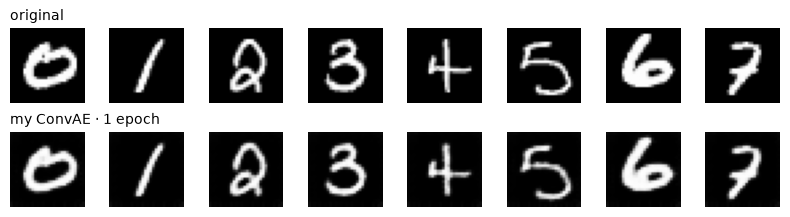

In [6]:
# 1 에폭 학습 · 나란히 보기 — 이 셀 안의 학습 함수를 씀
EPOCHS = 5

def train_p4(model, X, epochs=EPOCHS):
    torch.manual_seed(0)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(len(X))
        for i in range(0, len(X), 128):
            x = X[perm[i:i + 128]]
            opt.zero_grad()
            loss = F.mse_loss(model(x), x)
            loss.backward()
            opt.step()
        print(f"epoch {epoch + 1}  loss {loss.item():.4f}")
    return model


assert tuple(MyConvAE()(Xte[:1]).shape) == (1, 1, 28, 28), "[안내] 위 확인 셀의 마지막 모양부터 (1, 1, 28, 28) 로 맞추기"
torch.manual_seed(0)
my_cae = train_p4(MyConvAE(), Xtr[:10000])
show([("original", Xte), ("my ConvAE · 1 epoch", run(my_cae, Xte))])